# Cross-species integration via orthologs

Single-cell datasets from **different species** cannot be integrated directly:
their genes live in different symbol spaces. omicverse bridges them with
**one-to-one orthologs** fetched from Ensembl BioMart, then reuses its existing
batch-integration backends (Harmony / scVI / Concord / Seurat-CCA) to align the
datasets *across species*. This answers
[issue #856](https://github.com/omicverse/omicverse/issues/856).

The workflow has three steps, all in `ov.single`:

1. `get_orthologs(source, target)` — homologous-gene table from Ensembl BioMart.
2. `map_var_to_orthologs(adata, source, target)` — transfer one dataset onto the
   other species' gene symbols.
3. `cross_species_integrate([...], [...])` — align every dataset to a reference
   species, keep the shared orthologs, and integrate.

> **Scope.** This is the lightweight, ortholog-based route (unambiguous
> one-to-one genes). Graph-/embedding-based methods that also use many-to-many
> homology — **SAMap** (BLAST homology graph) and **SATURN** (protein
> language-model embeddings) — are heavier and complementary; they are not
> required for the common case handled here.

In [1]:
import omicverse as ov
import scanpy as sc
import numpy as np
import pandas as pd

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load two real datasets from different species

We use two reproducible, hematopoietic datasets shipped with scanpy:

- **Human** peripheral-blood mononuclear cells (`pbmc3k`) — mature T / B / NK /
  monocyte populations.
- **Mouse** myeloid progenitors (`paul15`) — bone-marrow erythroid / myeloid
  differentiation.

They share a **myeloid axis** (monocyte / granulocyte-monocyte progenitors) but
also carry species-/compartment-specific populations — a realistic cross-species
setting where good integration should mix the shared cells while preserving the
distinct ones.

In [2]:
adata_h = sc.datasets.pbmc3k()          # human, raw counts, gene symbols
adata_m = sc.datasets.paul15()          # mouse,  raw counts, gene symbols
adata_h.shape, adata_m.shape

((2700, 32738), (2730, 3451))

In [3]:
sc.pp.filter_genes(adata_h, min_cells=3)
sc.pp.filter_genes(adata_m, min_cells=3)
print('human genes:', list(adata_h.var_names[:4]))
print('mouse genes:', list(adata_m.var_names[:4]))

human genes: ['AL627309.1', 'AP006222.2', 'RP11-206L10.2', 'RP11-206L10.9']
mouse genes: ['0610007L01Rik', '0610009O20Rik', '0610010K14Rik', '0910001L09Rik']


## 2. Homologous-gene transfer (Ensembl BioMart)

`get_orthologs` queries Ensembl BioMart's `martservice` (over HTTPS) and returns
a one-to-one ortholog table. The result is cached under `data/orthologs/`, so
repeat calls are instant and offline.

In [4]:
ortho = ov.single.get_orthologs('mouse', 'human')   # mouse symbol -> human symbol
print('one-to-one mouse->human orthologs:', len(ortho))
ortho.head()

one-to-one mouse->human orthologs: 17065


,source_symbol,target_symbol,orthology_type
0,mt-Nd1,MT-ND1,ortholog_one2one
1,mt-Nd2,MT-ND2,ortholog_one2one
2,mt-Co1,MT-CO1,ortholog_one2one
3,mt-Co2,MT-CO2,ortholog_one2one
4,mt-Atp8,MT-ATP8,ortholog_one2one


We can transfer a single dataset onto another species' symbols with
`map_var_to_orthologs` — genes without a one-to-one ortholog are dropped, and the
original symbols are kept in `.var['source_symbol']`.

In [5]:
adata_m_human = ov.single.map_var_to_orthologs(adata_m, 'mouse', 'human')
print('mouse dataset on human symbols:', adata_m_human.shape)
adata_m_human.var.head(3)

mouse dataset on human symbols: (2730, 2797)


,n_cells,source_symbol
C9orf85,154,1110059E24Rik
C19orf12,393,1600014C10Rik
C11orf97,28,1700012B09Rik


## 3. Cross-species integration

`cross_species_integrate` does the whole alignment in one call: map every
dataset to the reference species (`human` here), restrict to the shared
orthologs, concatenate with a `species` batch label, then run the chosen
`batch_correction` backend. Here we use **Harmony**; swap `method='scVI'`,
`'Concord'`, or `'cca'` for other backends.

In [6]:
adata = ov.single.cross_species_integrate(
    [adata_h, adata_m], ['human', 'mouse'],
    ref_species='human', method='harmony',
    n_top_genes=2000, n_pcs=30)
adata.uns['cross_species']

...Begin using harmony to correct batch effect


computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (5430, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.13s)
🚀 Using PyTorch CUDA acceleration for Harmony
    Data: 30 PCs × 5430 cells
    Batch variables: ['species']
    Max iterations: 10
    Convergence threshold: 0.0001


    Initializing centroids (K=100) ... 

done


...

Harmony iteration 3/10:  10%|█         | 1/10 [00:00<00:01,  6.28it/s]

Harmony converged after 3 iterations:  10%|█         | 1/10 [00:00<00:01,  6.28it/s]

Harmony converged after 3 iterations:  20%|██        | 2/10 [00:00<00:01,  6.26it/s]


✅ Harmony converged after 3 iterations

╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 2.1714s                                                 │
│  Shape:    5,430 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│                                                                    │
│  ● OBSM   │ ✚ X_harmony (array, 5430x30)                           │
│           │ ✚ X_pca_harmony (array, 5430x30)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


{'ref_species': 'human',
 'species': ['human', 'mouse'],
 'n_common_orthologs': 2531,
 'method': 'harmony',
 'orthology_type': 'one2one'}

## 4. Visualise and evaluate the integration

We build a neighbour graph on the Harmony embedding, cluster, and compare the
species mixing **before** (raw PCA) and **after** integration.

In [7]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1.0, flavor='igraph',
             n_iterations=2, directed=False)

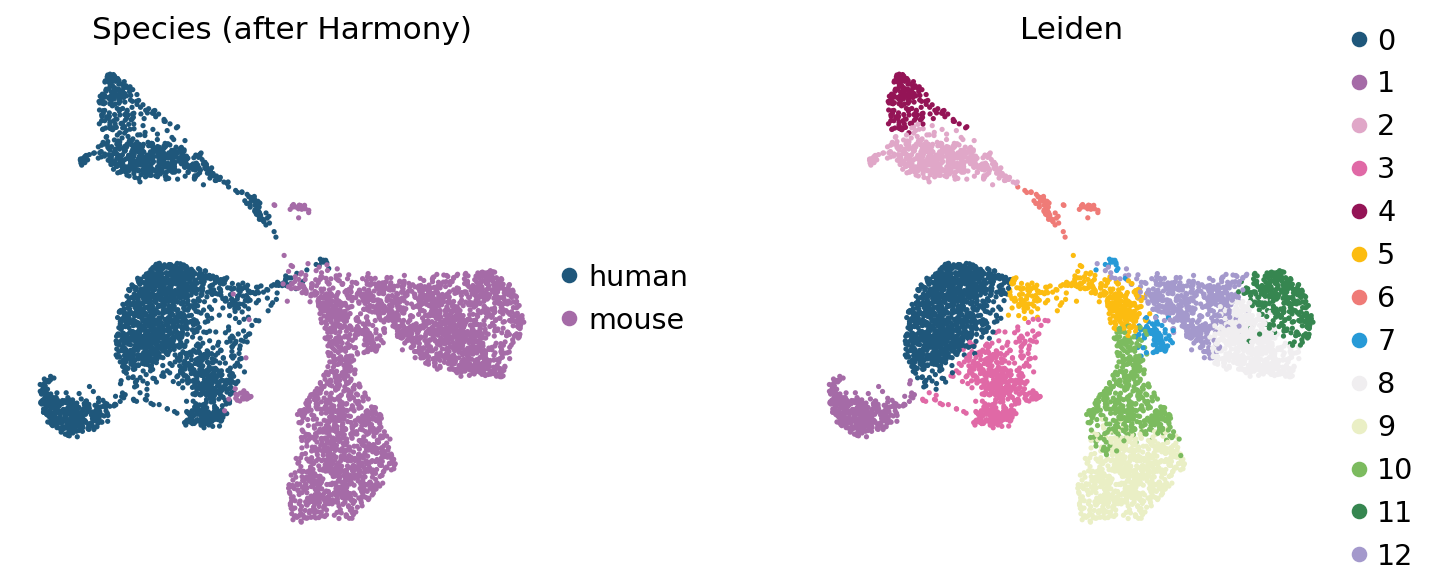

In [8]:
sc.pl.umap(adata, color=['species', 'leiden'], wspace=0.35,
           frameon=False, title=['Species (after Harmony)', 'Leiden'])

Quantify mixing: the fraction of clusters that contain **both** species,
before vs after integration. Shared myeloid clusters should mix after Harmony;
lineage-specific clusters correctly stay species-pure.

In [9]:
sc.pp.neighbors(adata, use_rep='X_pca', n_neighbors=15, key_added='pre')
sc.tl.leiden(adata, resolution=1.0, flavor='igraph', n_iterations=2,
             directed=False, neighbors_key='pre', key_added='leiden_pre')

def frac_mixed(key):
    t = pd.crosstab(adata.obs[key], adata.obs['species'])
    return ((t['human'] > 0) & (t['mouse'] > 0)).mean()

print(f'clusters with both species  — before: {frac_mixed("leiden_pre"):.2f}'
      f'   after Harmony: {frac_mixed("leiden"):.2f}')

clusters with both species  — before: 0.00   after Harmony: 0.31


In [10]:
pd.crosstab(adata.obs['leiden'], adata.obs['species'])

species,human,mouse
leiden,,
0,1096,0
1,340,0
2,452,0
3,459,28
4,183,0
5,105,228
6,52,29
7,13,93
8,0,518


## Summary

- `ov.single.get_orthologs` / `map_var_to_orthologs` — homologous-gene transfer
  between any Ensembl species (human, mouse, rat, zebrafish, pig, macaque, fly …).
- `ov.single.cross_species_integrate` — one-call cross-species integration on the
  shared one-to-one orthologs, reusing omicverse's `batch_correction` backends
  (`harmony`, `scVI`, `Concord`, `cca`, …).

Harmony pulls the **shared myeloid populations** of the two species together while
leaving lineage-specific populations (human lymphocytes, mouse erythroid
progenitors) correctly apart — the expected behaviour for biologically partly
overlapping datasets.

For homology that is *not* one-to-one (large evolutionary distances, gene
duplications), consider **SAMap** or **SATURN** as complementary tools.